In [1]:
# 1. Load and preprocess image 
from skimage import io, exposure
import numpy as np

img_path = "C:/Users/Acer/Downloads/real_data/real_data/Figure7_2D_3D/2D/22_Pr01_0_594.tif"
img = io.imread(img_path)
print("Image shape:", img.shape)

# Normalize each channel
channels = [exposure.rescale_intensity(img[..., i], out_range=(0,1)) for i in range(img.shape[-1])]
ch1, ch2, ch3 = channels

Image shape: (1440, 1432, 3)


In [3]:
# 2. Visualize in Napari
%gui qt
import napari

viewer = napari.Viewer()
colors = ["red", "green", "blue"]

for i, ch in enumerate(channels):
    viewer.add_image(ch, name=f"Channel {i+1}", colormap=colors[i], blending="additive")

# Overlay for visual colocalization (Ch1 vs Ch2)
coloc_mask = (ch1 > 0.3) & (ch2 > 0.3)
viewer.add_labels(coloc_mask.astype(np.uint8), name="Colocalization (yellow)", color={1: "yellow"})

napari.run()

C:\Users\Acer\anaconda3\envs\napari_env\lib\site-packages\napari\components\viewer_model.py:10: FutureWarning: Labels.color is deprecated since 0.4.19 and will be removed in 0.5.0, please set Labels.colormap directly with an instance of napari.utils.colormaps.DirectLabelColormap instead.
  TYPE_CHECKING,


In [5]:
pip install -U POT


Note: you may need to restart the kernel to use updated packages.


In [7]:
# 3. Colocalization Metrics and Utilities
from scipy.stats import pearsonr
import ot
import matplotlib.pyplot as plt

# Metric Functions
def pearson_coeff(ch1, ch2):
    """Pearson correlation coefficient."""
    if np.sum(ch1) == 0 or np.sum(ch2) == 0:
        return np.nan
    return pearsonr(ch1.ravel(), ch2.ravel())[0]

def manders_coeff(ch1, ch2):
    """Manders overlap coefficient."""
    if np.sum(ch1) == 0 or np.sum(ch2) == 0:
        return np.nan
    ch1 = ch1.ravel()
    ch2 = ch2.ravel()
    return np.sum(ch1[ch2 > 0]) / np.sum(ch1)

def compute_otc_curve(ch1, ch2, num_scales=5, reg=0.5):
    """Stable histogram-based OTC with smoothing to avoid Sinkhorn warnings."""
    bins = 50
    EPS = 1e-6

    # Smooth histograms to avoid zero bins
    h1, _ = np.histogram(ch1, bins=bins, range=(0, 1), density=True)
    h2, _ = np.histogram(ch2, bins=bins, range=(0, 1), density=True)

    h1 = h1 + EPS
    h2 = h2 + EPS

    h1 = h1 / h1.sum()
    h2 = h2 / h2.sum()

    # Cost matrix
    x = np.arange(bins).reshape(-1, 1).astype(float)
    C = ot.dist(x, x)
    C = C / C.max()
    C = C.astype(float)

    scales = np.linspace(0.5, 2.0, num_scales)
    otc_vals = []

    for t in scales:
        Ct = C * t
        try:
            plan = ot.sinkhorn(h1, h2, Ct, reg=reg, numItermax=500)
            otc_vals.append(np.sum(plan * Ct))
        except Exception as e:
            print(f"Sinkhorn failed at scale {t:.2f}: {e}")
            otc_vals.append(np.nan)

    return scales, otc_vals

In [9]:
# 4. ROI Selection (Avoid empty areas)
def find_nonempty_roi(ch1, ch2, size=128, min_sum=50):
    h, w = ch1.shape
    for i in range(0, h-size, size):
        for j in range(0, w-size, size):
            roi1, roi2 = ch1[i:i+size, j:j+size], ch2[i:i+size, j:j+size]
            if np.sum(roi1) > min_sum and np.sum(roi2) > min_sum:
                return roi1, roi2
    return None, None

roi_ch1, roi_ch2 = find_nonempty_roi(ch1, ch2)
if roi_ch1 is None:
    raise ValueError("No suitable ROI found. Try another region with signal.")

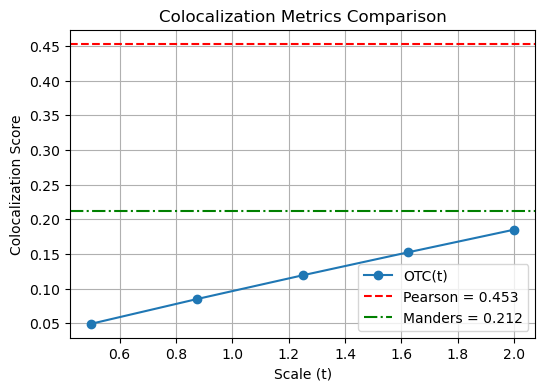

Pearson: 0.453
Manders: 0.212
OTC values: [0.04949 0.0851  0.11934 0.15254 0.18508]


In [11]:
# 5. Compute and Compare Metrics
pearson_val = pearson_coeff(roi_ch1, roi_ch2)
manders_val = manders_coeff(roi_ch1, roi_ch2)
scales, otc_vals = compute_otc_curve(roi_ch1, roi_ch2)

# --- Plot ---
plt.figure(figsize=(6,4))
plt.plot(scales, otc_vals, '-o', label="OTC(t)")
plt.axhline(y=pearson_val, color='r', linestyle='--', label=f"Pearson = {pearson_val:.3f}")
plt.axhline(y=manders_val, color='g', linestyle='-.', label=f"Manders = {manders_val:.3f}")
plt.xlabel("Scale (t)")
plt.ylabel("Colocalization Score")
plt.title("Colocalization Metrics Comparison")
plt.legend()
plt.grid(True)
plt.show()

print(f"Pearson: {pearson_val:.3f}")
print(f"Manders: {manders_val:.3f}")
print("OTC values:", np.round(otc_vals, 5))

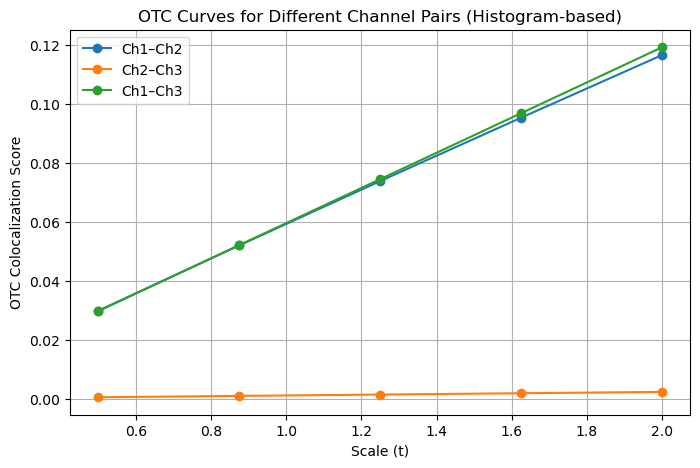

In [13]:
# 6. Multi-Channel OTC Comparison
results = {
    "Ch1–Ch2": compute_otc_curve(ch1, ch2),
    "Ch2–Ch3": compute_otc_curve(ch2, ch3),
    "Ch1–Ch3": compute_otc_curve(ch1, ch3)
}

plt.figure(figsize=(8,5))
for label, (s, o) in results.items():
    plt.plot(s, o, marker='o', label=label)

plt.title("OTC Curves for Different Channel Pairs (Histogram-based)")
plt.xlabel("Scale (t)")
plt.ylabel("OTC Colocalization Score")
plt.legend()
plt.grid(True)
plt.show()

In [1]:
import ot
print(ot.__version__)

0.9.6.post1


In [3]:
pip install -U POT==0.9.9

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement POT==0.9.9 (from versions: 0.1.1, 0.1.2, 0.1.3, 0.1.4, 0.1.5, 0.1.6, 0.1.7, 0.1.8, 0.1.9, 0.1.10, 0.1.11, 0.1.12, 0.2, 0.3, 0.3.1, 0.4.0, 0.5.1, 0.6.0, 0.7.0, 0.7.0.post1, 0.8.0, 0.8.1.0, 0.8.2, 0.9.0, 0.9.1, 0.9.2, 0.9.3, 0.9.4, 0.9.5, 0.9.6, 0.9.6.post1)
ERROR: No matching distribution found for POT==0.9.9
